In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

# 1. Cargar el archivo .pt
data = torch.load("embeddings.pt")
records = data["records"]

# 2. Convertir a listas para procesamiento
# Extraemos el embedding (tensor -> numpy), la categoría y el tipo (image/sketch)
embeddings_list = [r["embedding"].numpy() for r in records]
categories = [r["category"] for r in records]
dtypes = [r["dtype"] for r in records]

# Convertir a matriz numpy para sklearn
X = np.stack(embeddings_list)
df = pd.DataFrame({
    "category": categories,
    "dtype": dtypes
})

print(f"Dataset cargado: {X.shape[0]} vectores de dimensión {X.shape[1]}")
print(f"Categorías únicas: {len(df['category'].unique())}")

Dataset cargado: 1903 vectores de dimensión 768
Categorías únicas: 46


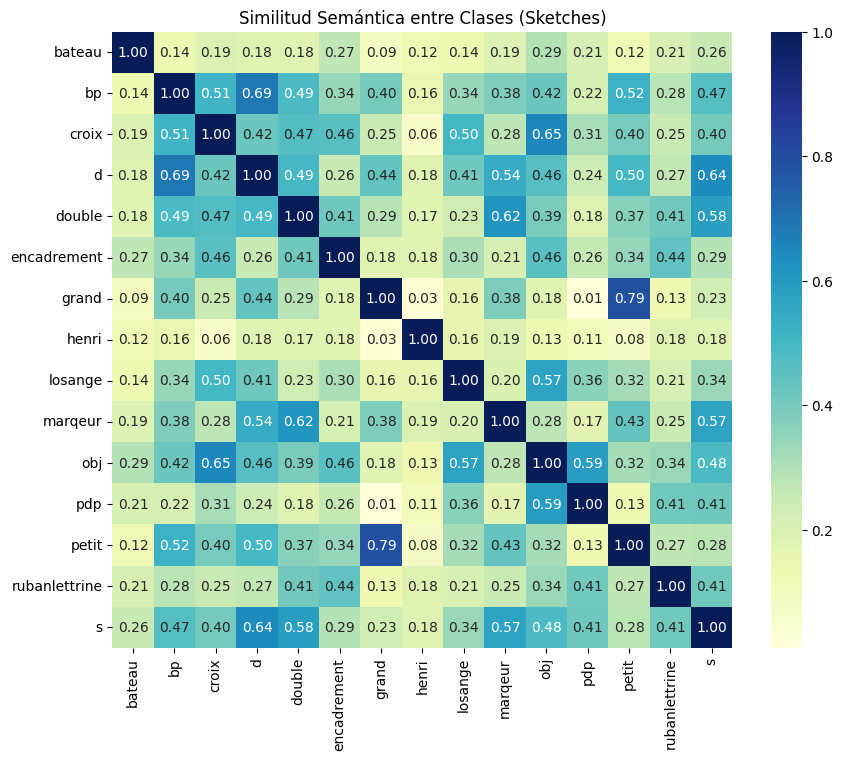

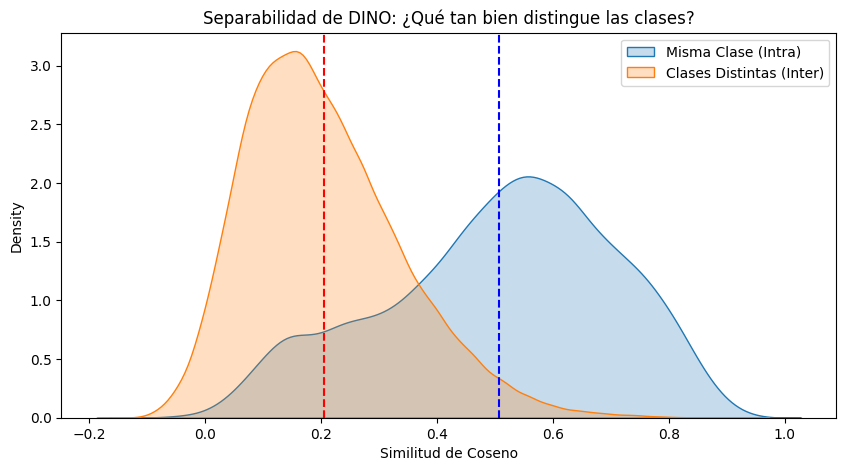

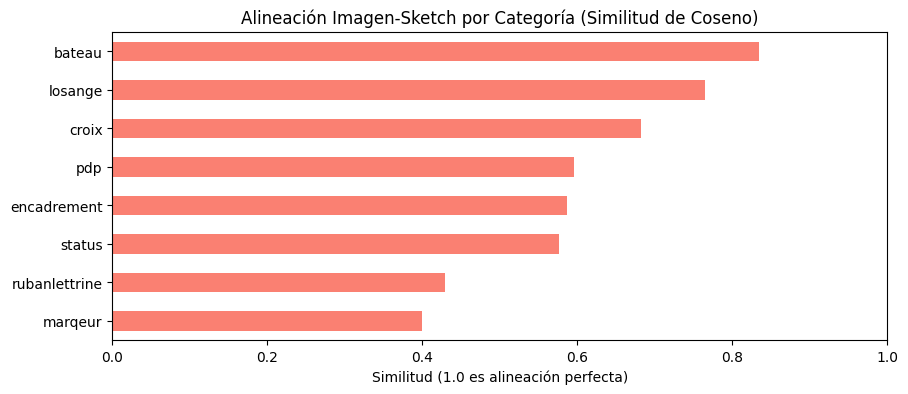

In [2]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE

# 1. Preparación de Tensores
# Separamos imágenes de sketches para comparar dominios
mask_sketch = df['dtype'] == 'sketch'
mask_image = df['dtype'] == 'image'

X_sketches = X[mask_sketch]
labels_sketches = df[mask_sketch]['category'].values

X_images = X[mask_image]
labels_images = df[mask_image]['category'].values

# ========================================================
# ANÁLISIS 1: Matriz de Similitud entre Categorías (Heatmap)
# ========================================================
# Esto nos dice qué categorías confunde DINO (ej. ¿se parece 'perro' a 'gato'?)
def plot_category_similarity(features, labels, title):
    unique_cats = sorted(list(set(labels)))
    # Solo tomamos las primeras 15 para que el gráfico sea legible
    unique_cats = unique_cats[:15] 
    
    centroids = []
    for cat in unique_cats:
        cat_features = features[labels == cat]
        centroids.append(cat_features.mean(axis=0))
    
    sim_matrix = cosine_similarity(centroids)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(sim_matrix, xticklabels=unique_cats, yticklabels=unique_cats, 
                annot=True, cmap='YlGnBu', fmt=".2f")
    plt.title(f"Similitud Semántica entre Clases ({title})")
    plt.show()

plot_category_similarity(X_sketches, labels_sketches, "Sketches")

# ========================================================
# ANÁLISIS 2: Distribución de Similitud Intra-clase vs Inter-clase
# ========================================================
# Un buen modelo debería tener similitudes altas para la misma clase 
# y bajas para clases distintas.
def plot_similarity_distribution(features, labels):
    # Tomamos una muestra para no saturar el cálculo
    idx = np.random.choice(len(features), min(500, len(features)), replace=False)
    sample_features = features[idx]
    sample_labels = labels[idx]
    
    sim_full = cosine_similarity(sample_features)
    
    intra_sims = []
    inter_sims = []
    
    for i in range(len(sample_labels)):
        for j in range(i + 1, len(sample_labels)):
            if sample_labels[i] == sample_labels[j]:
                intra_sims.append(sim_full[i, j])
            else:
                inter_sims.append(sim_full[i, j])
                
    plt.figure(figsize=(10, 5))
    sns.kdeplot(intra_sims, label="Misma Clase (Intra)", fill=True)
    sns.kdeplot(inter_sims, label="Clases Distintas (Inter)", fill=True)
    plt.axvline(np.mean(intra_sims), color='blue', linestyle='--')
    plt.axvline(np.mean(inter_sims), color='red', linestyle='--')
    plt.title("Separabilidad de DINO: ¿Qué tan bien distingue las clases?")
    plt.xlabel("Similitud de Coseno")
    plt.legend()
    plt.show()

plot_similarity_distribution(X_sketches, labels_sketches)

# ========================================================
# ANÁLISIS 3: El "Domain Gap" (Imágenes vs Sketches)
# ========================================================
# Graficamos la distancia promedio de cada categoría entre sus fotos y sus sketches.
common_cats = set(labels_images).intersection(set(labels_sketches))
gap_results = {}

for cat in list(common_cats)[:10]: # Top 10 categorías comunes
    img_center = X_images[labels_images == cat].mean(axis=0).reshape(1, -1)
    sket_center = X_sketches[labels_sketches == cat].mean(axis=0).reshape(1, -1)
    gap_results[cat] = cosine_similarity(img_center, sket_center)[0][0]

gap_series = pd.Series(gap_results).sort_values()
plt.figure(figsize=(10, 4))
gap_series.plot(kind='barh', color='salmon')
plt.title("Alineación Imagen-Sketch por Categoría (Similitud de Coseno)")
plt.xlabel("Similitud (1.0 es alineación perfecta)")
plt.xlim(0, 1)
plt.show()

Calculando similitud para 456 consultas contra 1447 imágenes...


/var/folders/js/wns9brx16sqfldmkkfbn28cm0000gn/T/ipykernel_48553/3920067421.py:85: RuntimeWarning: Mean of empty slice.
  s = sim_matrix[labels_query == c1][:, labels_gallery == c2].mean()
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


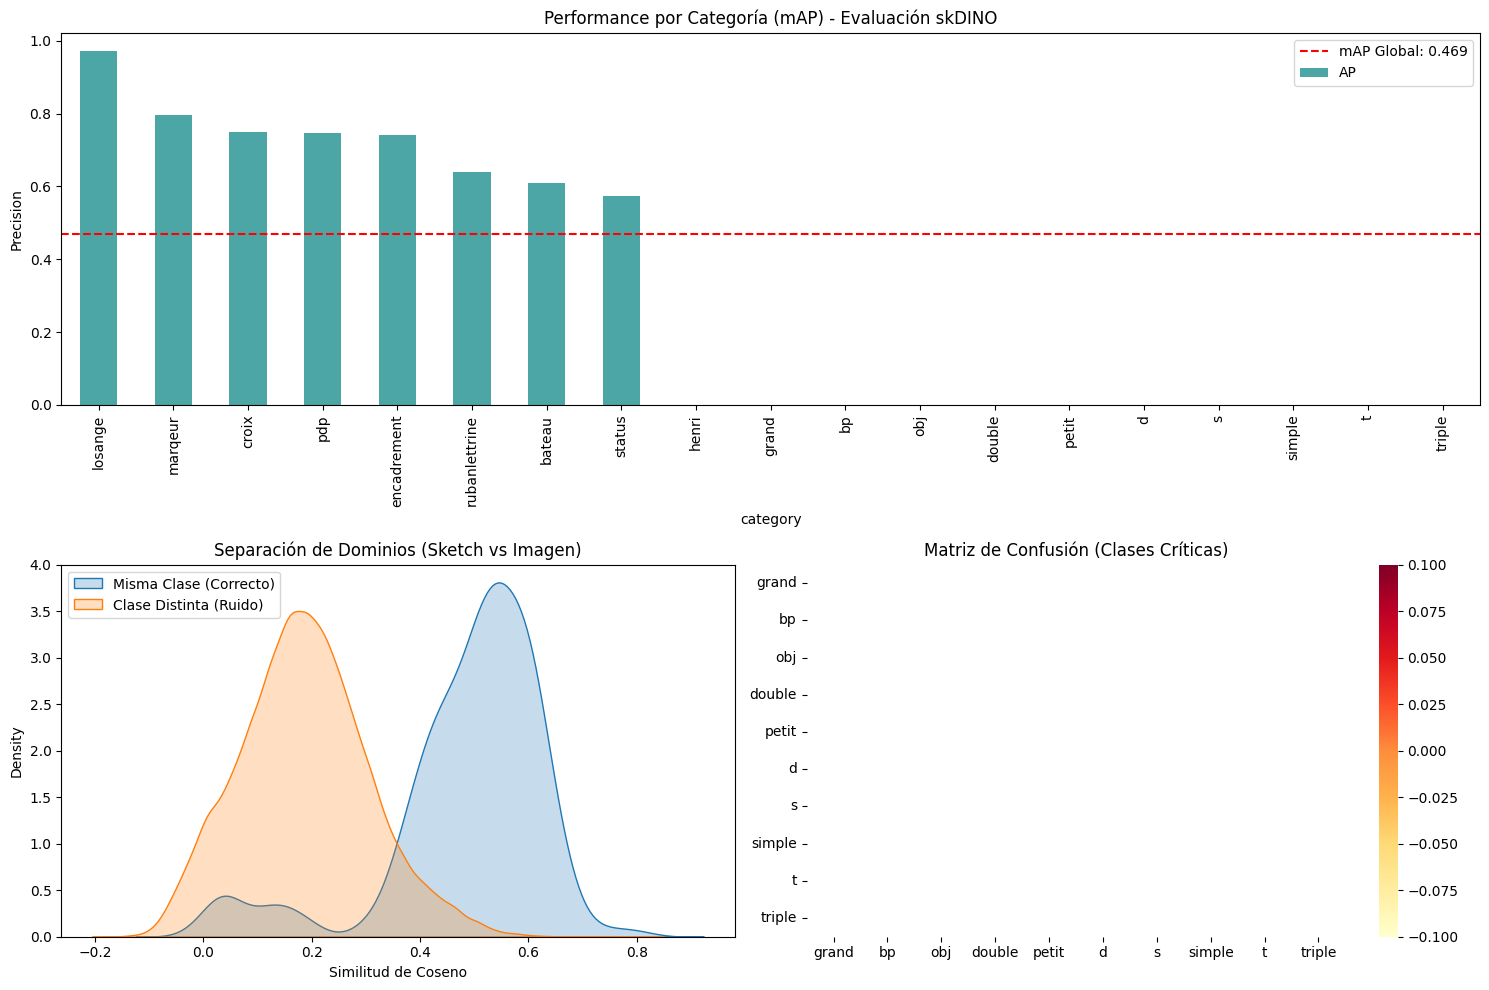


>>> RESULTADO FINAL mAP: 0.4694


In [3]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

# 1. Carga de datos
data = torch.load("embeddings.pt")
df = pd.DataFrame(data["records"])

# Convertir la columna de embeddings (tensores) a una matriz numpy
X = np.stack([r.numpy() for r in df['embedding']])
categories = df['category'].values
dtypes = df['dtype'].values

# Separar Queries (sketches) y Gallery (imágenes reales)
is_sketch = (dtypes == 'sketch')
X_query = X[is_sketch]
labels_query = categories[is_sketch]

X_gallery = X[~is_sketch]
labels_gallery = categories[~is_sketch]

# 2. Calcular Similitud de Coseno (Query x Gallery)
print(f"Calculando similitud para {len(X_query)} consultas contra {len(X_gallery)} imágenes...")
sim_matrix = cosine_similarity(X_query, X_gallery)

# 3. Cálculo de Average Precision (AP) por cada consulta
def calculate_ap(sim_scores, q_label, g_labels):
    # Ordenar galería por similitud descendente
    indices = np.argsort(-sim_scores)
    sorted_labels = g_labels[indices]
    # Relevancia binaria (1 si es la misma categoría, 0 si no)
    relevance = (sorted_labels == q_label).astype(int)
    
    if np.sum(relevance) == 0: return 0
    
    # Precisión acumulada en cada acierto
    precisions = np.cumsum(relevance) / (np.arange(len(relevance)) + 1)
    return np.sum(precisions * relevance) / np.sum(relevance)

aps = [calculate_ap(sim_matrix[i], labels_query[i], labels_gallery) for i in range(len(X_query))]
mAP_total = np.mean(aps)

# --- GENERACIÓN DE GRÁFICAS ---

plt.figure(figsize=(15, 10))

# GRÁFICA 1: mAP por Categoría (Performance Semántico)
# Evalúa la Tabla 3 y 4 del paper [cite: 591, 592]
plt.subplot(2, 1, 1)
df_res = pd.DataFrame({'category': labels_query, 'AP': aps})
cat_performance = df_res.groupby('category')['AP'].mean().sort_values(ascending=False)
cat_performance.plot(kind='bar', color='teal', alpha=0.7)
plt.axhline(y=mAP_total, color='r', linestyle='--', label=f'mAP Global: {mAP_total:.3f}')
plt.title("Performance por Categoría (mAP) - Evaluación skDINO")
plt.ylabel("Precision")
plt.legend()

# GRÁFICA 2: Distribución de Similitudes (Separabilidad)
# Evalúa qué tan bien DINO cierra el "Domain Gap" [cite: 469]
plt.subplot(2, 2, 3)
intra_class = []
inter_class = []
for i in range(min(100, len(X_query))): # Muestreo para velocidad
    intra_class.extend(sim_matrix[i][labels_gallery == labels_query[i]])
    inter_class.extend(sim_matrix[i][labels_gallery != labels_query[i]])

sns.kdeplot(intra_class, label="Misma Clase (Correcto)", fill=True)
sns.kdeplot(inter_class, label="Clase Distinta (Ruido)", fill=True)
plt.title("Separación de Dominios (Sketch vs Imagen)")
plt.xlabel("Similitud de Coseno")
plt.legend()

# GRÁFICA 3: Top Confusiones (Heatmap de Error)
# Ayuda a identificar por qué algunas clases fallan [cite: 581]
plt.subplot(2, 2, 4)
top_cats = cat_performance.tail(10).index # Las 10 categorías con peor desempeño
conf_matrix = []
for c1 in top_cats:
    row = []
    for c2 in top_cats:
        # Similitud promedio entre bocetos de C1 e imágenes de C2
        s = sim_matrix[labels_query == c1][:, labels_gallery == c2].mean()
        row.append(s)
    conf_matrix.append(row)

sns.heatmap(conf_matrix, xticklabels=top_cats, yticklabels=top_cats, cmap="YlOrRd")
plt.title("Matriz de Confusión (Clases Críticas)")

plt.tight_layout()
plt.show()

print(f"\n>>> RESULTADO FINAL mAP: {mAP_total:.4f}")

Clases detectadas con mAP > 0: 8 de 19


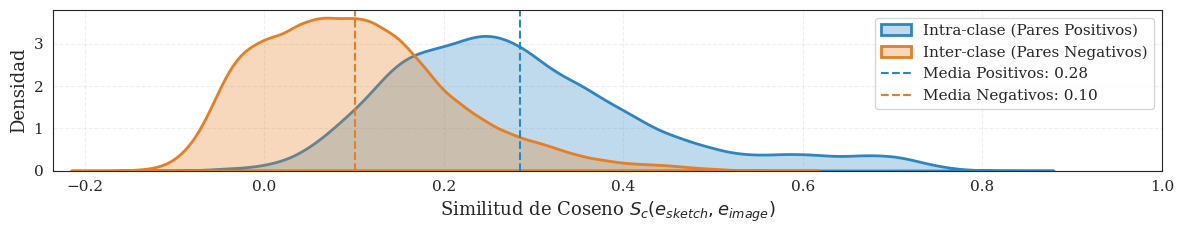

Análisis completado. Margen (Gap): 0.1827


In [5]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

# 1. Configuración estética para formato de publicación (Paper)
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 15,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
    "text.usetex": False
})

try:
    # 2. Carga y preparación inicial
    data = torch.load("embeddings.pt")
    df = pd.DataFrame(data["records"])
    X = np.stack([r.numpy() for r in df['embedding']])
    
    # Separación base
    mask_sketch = (df['dtype'] == 'sketch').values
    X_query = X[mask_sketch]
    labels_query = df['category'].values[mask_sketch]
    X_gallery = X[~mask_sketch]
    labels_gallery = df['category'].values[~mask_sketch]

    # 3. Cálculo de AP por consulta para filtrar clases con mAP > 0
    sim_matrix = cosine_similarity(X_query, X_gallery)
    
    def get_ap(sims, q_label, g_labels):
        sort_idx = np.argsort(-sims)
        rel = (g_labels[sort_idx] == q_label).astype(int)
        if np.sum(rel) == 0: return 0.0
        ranks = np.arange(1, len(rel) + 1)
        return np.sum((np.cumsum(rel) / ranks) * rel) / np.sum(rel)

    # Calcular AP para cada sketch
    aps = [get_ap(sim_matrix[i], labels_query[i], labels_gallery) for i in range(len(X_query))]
    df_aps = pd.DataFrame({'category': labels_query, 'AP': aps})
    
    # Identificar clases con mAP > 0
    mAP_per_class = df_aps.groupby('category')['AP'].mean()
    clases_validas = mAP_per_class[mAP_per_class > 0].index.tolist()
    
    print(f"Clases detectadas con mAP > 0: {len(clases_validas)} de {len(mAP_per_class)}")

    # 4. Filtrar datos para el gráfico de Separación de Dominios
    intra_clase = []
    inter_clase = []
    
    for i in range(len(X_query)):
        # Solo procesamos si la categoría de la consulta tiene mAP > 0
        if labels_query[i] in clases_validas:
            categoria_actual = labels_query[i]
            
            # Filtramos la galería para comparar solo contra clases válidas
            mask_gallery_valid = np.isin(labels_gallery, clases_validas)
            labels_g_filtered = labels_gallery[mask_gallery_valid]
            sims_filtered = sim_matrix[i][mask_gallery_valid]
            
            mascara_positivos = (labels_g_filtered == categoria_actual)
            
            intra_clase.extend(sims_filtered[mascara_positivos])
            inter_clase.extend(sims_filtered[~mascara_positivos])

    # 5. Generación del gráfico alargado
    plt.figure(figsize=(12, 2.5))
    
    color_pos = "#2E86C1" # Azul
    color_neg = "#E67E22" # Naranja
    
    sns.kdeplot(intra_clase, label="Intra-clase (Pares Positivos)", 
                fill=True, color=color_pos, linewidth=2, alpha=0.3)
    sns.kdeplot(inter_clase, label="Inter-clase (Pares Negativos)", 
                fill=True, color=color_neg, linewidth=2, alpha=0.3)

    plt.axvline(np.mean(intra_clase), color=color_pos, linestyle="--", 
                label=f"Media Positivos: {np.mean(intra_clase):.2f}")
    plt.axvline(np.mean(inter_clase), color=color_neg, linestyle="--", 
                label=f"Media Negativos: {np.mean(inter_clase):.2f}")

    #plt.title(f"Separación de Dominios (Solo Clases con mAP > 0: {len(clases_validas)} clases)", pad=15)
    plt.xlabel(r"Similitud de Coseno $S_c(e_{sketch}, e_{image})$")
    plt.ylabel("Densidad")
    plt.legend(loc="upper right", frameon=True)
    
    plt.xlim(min(inter_clase)-0.05, 1.0)
    plt.tight_layout()
    plt.savefig("separacion_dominios_filtrado.png", dpi=300)
    plt.show()

    print(f"Análisis completado. Margen (Gap): {np.mean(intra_clase) - np.mean(inter_clase):.4f}")

except Exception as e:
    print(f"Ocurrió un error: {e}")

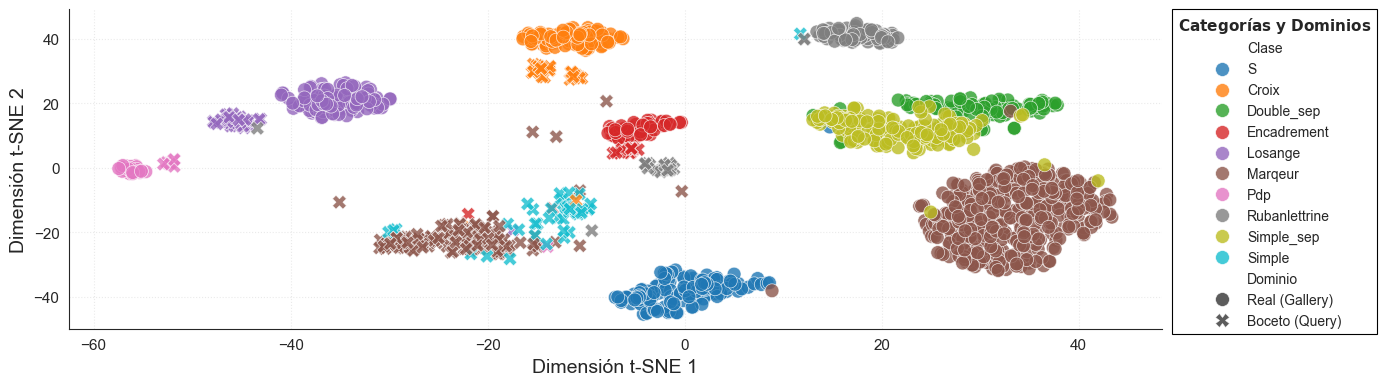

In [6]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

# 1. Configuración de estilo "Paper" consistente
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "legend.fontsize": 10,
    "axes.grid": True,
    "grid.alpha": 0.2,
    "grid.linestyle": "--"
})

# 2. Carga y Procesamiento (Se asume que 'df' ya tiene las coords t-SNE o se calculan)
try:
    data = torch.load("embeddings.pt")
    df = pd.DataFrame(data["records"])
    X = np.stack([r.numpy() for r in df['embedding']])

    # Cálculo de t-SNE
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, init='pca')
    X_2d = tsne.fit_transform(X)
    df['tsne_x'], df['tsne_y'] = X_2d[:, 0], X_2d[:, 1]

    # Filtro de categorías top
    n_categorias = 10
    top_cats = df['category'].value_counts().nlargest(n_categorias).index
    df_plot = df[df['category'].isin(top_cats)].copy()

    df_plot['Clase'] = df_plot['category'].str.capitalize()
    df_plot['Dominio'] = df_plot['dtype'].map({'sketch': 'Boceto (Query)', 'image': 'Real (Gallery)'})

    # 3. Creación del Gráfico Achicado Verticalmente
    plt.figure(figsize=(14, 4)) # Más delgado verticalmente
    sns.set_style("white")

    palette = sns.color_palette("tab10", n_colors=len(top_cats))

    scatter = sns.scatterplot(
        data=df_plot, 
        x='tsne_x', 
        y='tsne_y', 
        hue='Clase', 
        style='Dominio',
        palette=palette,
        s=100, # Un poco más pequeño para evitar saturación
        alpha=0.8,
        edgecolor='w',
        linewidth=0.5,
        markers={'Boceto (Query)': 'X', 'Real (Gallery)': 'o'}
    )

    # 4. Refinamiento de Ejes y Título
    #plt.title(r"$\mathbf{Visualización\ t-SNE:\ Alineación\ de\ Dominios\ skDINO}$", pad=15)
    plt.xlabel("Dimensión t-SNE 1")
    plt.ylabel("Dimensión t-SNE 2")
    
    # Limpieza visual (Despine)
    sns.despine(trim=False)

    # 5. Leyenda Opaca y Mejorada
    handles, labels = scatter.get_legend_handles_labels()
    
    # Configuramos la leyenda para que sea opaca y con borde negro
    leg = plt.legend(
        handles=handles, 
        labels=labels,
        title=r"$\mathbf{Categorías\ y\ Dominios}$",
        bbox_to_anchor=(1.01, 1), 
        loc='upper left', 
        borderaxespad=0,
        frameon=True,
        fancybox=False
    )
    leg.get_frame().set_alpha(1.0) # Opacidad total
    leg.get_frame().set_edgecolor('black') # Borde definido
    leg.get_frame().set_linewidth(0.8)

    plt.grid(True, linestyle=':', alpha=0.4)
    plt.tight_layout()
    plt.savefig("tsne_paper_style.png", dpi=300, bbox_inches="tight")
    plt.show()

except Exception as e:
    print(f"Ocurrió un error: {e}")

/var/folders/js/wns9brx16sqfldmkkfbn28cm0000gn/T/ipykernel_25297/2129644245.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


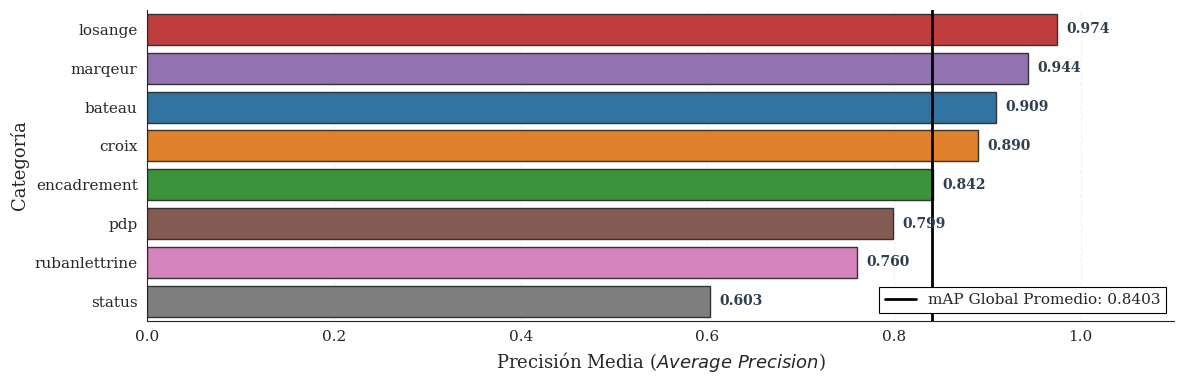

Gráfico guardado. mAP Global Final: 0.8403


In [10]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

# 1. CONFIGURACIÓN ESTÉTICA (Consistente con el código anterior)
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 15,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "axes.grid": True,
    "grid.alpha": 0.2,
    "grid.linestyle": "--",
    "text.usetex": False 
})

try:
    # 2. CARGA Y FILTRADO DE DATOS
    data = torch.load("embeddings.pt")
    df = pd.DataFrame(data["records"])
    X = np.stack([r.numpy() for r in df['embedding']])
    
    cats_sketches = set(df[df['dtype'] == 'sketch']['category'])
    cats_images = set(df[df['dtype'] == 'image']['category'])
    clases_comunes = sorted(list(cats_sketches.intersection(cats_images)))

    mask = df['category'].isin(clases_comunes)
    df_f = df[mask].copy()
    X_f = X[mask.values]

    is_q = (df_f['dtype'] == 'sketch').values
    X_q, labels_q = X_f[is_q], df_f['category'].values[is_q]
    X_g, labels_g = X_f[~is_q], df_f['category'].values[~is_q]

    # 3. CÁLCULO DE MÉTRICAS (mAP)
    def calcular_ap(sims, q_label, g_labels):
        idx = np.argsort(-sims)
        relevancia = (g_labels[idx] == q_label).astype(int)
        if np.sum(relevancia) == 0: return 0.0
        ranks = np.arange(1, len(relevancia) + 1)
        return np.sum((np.cumsum(relevancia) / ranks) * relevancia) / np.sum(relevancia)

    sim_mat = cosine_similarity(X_q, X_g)
    aps = [calcular_ap(sim_mat[i], labels_q[i], labels_g) for i in range(len(X_q))]
    
    res_df = pd.DataFrame({'Categoria': labels_q, 'AP': aps})
    map_clases = res_df.groupby('Categoria')['AP'].mean().sort_values(ascending=False)
    map_global = map_clases.mean()

    # ========================================================
    # 4. GENERACIÓN DEL GRÁFICO CON COLORES CONSISTENTES
    # ========================================================
    plt.figure(figsize=(12, 4)) # Un poco más alto para legibilidad
    
    # CREACIÓN DE MAPEO DE COLORES FIJO
    # Usamos 'tab10' como en tu t-SNE original para que "Silla" sea del mismo color en ambos
    categorias_ordenadas = sorted(clases_comunes)
    palette_base = sns.color_palette("tab10", n_colors=len(categorias_ordenadas))
    color_map = dict(zip(categorias_ordenadas, palette_base))

    # Asignamos los colores según el orden de mAP actual
    colores_barras = [color_map[cat] for cat in map_clases.index]

    ax = sns.barplot(
        x=map_clases.values, 
        y=map_clases.index, 
        palette=colores_barras, # Aplicamos la lista de colores mapeados
        edgecolor="0.2", 
        linewidth=1
    )

    # Línea de mAP Global
    plt.axvline(x=map_global, color="#000000", linestyle='-', linewidth=2,
                label=f'mAP Global Promedio: {map_global:.4f}')

    plt.xlabel(r"Precisión Media ($Average\ Precision$)")
    plt.ylabel("Categoría")
    plt.xlim(0, 1.1) # Espacio extra para los números
    sns.despine(left=False, bottom=False)

    # Añadir valores numéricos
    for i, v in enumerate(map_clases.values):
        ax.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=10, 
                fontweight='bold', color='#2C3E50')

    # Leyenda Opaca
    leg = plt.legend(loc="lower right", frameon=True, fancybox=False)
    leg.get_frame().set_alpha(1.0)
    leg.get_frame().set_edgecolor('black')
    leg.get_frame().set_linewidth(0.8)

    plt.grid(axis='x', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.savefig("map_categorias_consistente.png", dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Gráfico guardado. mAP Global Final: {map_global:.4f}")

except Exception as e:
    print(f"Error: {e}")